# 05 — Paper Figures (definitive)

This is the **single authoritative source** for all figures that appear in the final
6-page ACM paper. Notebooks 03 and 04 are kept for exploration and audit but do not
feed the paper.

**Data dependencies**
- `data/processed/monthly_frames.csv` — aggregated monthly frame counts (Figures 1 & 2)
- `data/interim/gdelt_preprocessed.parquet` — per-article corpus (Figure 3; optional Figure 4)

**Outputs** → `paper/figures/`
| File | Figure | Answers |
|------|--------|---------|
| `fig1_volume_frames.png` | Volume + Frame evolution (2-panel, 2-col wide) | RQ1 + RQ2 |
| `fig2_milestone_effects.png` | Milestone event study — 1×4 grid (primary) | RQ3 |
| `fig2b_slope_chart.png` | Milestone slope chart — all 7 milestones (alternative) | RQ3 |
| `fig3_regional.png` | Regional frame distribution — horizontal grouped bars | Regional |
| `fig4_tone_by_frame.png` | Tone by dominant frame (optional, off by default) | Supplementary |

In [4]:
# 0. Setup — run this first; all subsequent cells depend on these constants.
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

from src.analysis import (
    load_agg,
    monthly_volume_agg, frame_shares_agg, event_study_agg,
    region_comparison,
)
from src.dictionaries import MILESTONES

# --- ACM 2-column figure widths (inches) ---
ONE_COL_IN = 3.33
TWO_COL_IN = 7.0

FIGURES = Path('../paper/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Frame display order, colors, and labels ---
# Color palette: Tableau-10 subset, distinguishable in greyscale print.
FRAME_COLORS = {
    'innovation_opportunity':       '#4e79a7',
    'risk_safety':                  '#e15759',
    'regulation_governance':        '#76b7b2',
    'rights_privacy':               '#f28e2b',
    'economic_competition_labour':  '#59a14f',
    'misinformation_integrity':     '#b07aa1',
}
FRAME_LABELS = {
    'innovation_opportunity':       'Innovation & Opportunity',
    'risk_safety':                  'Risk & Safety',
    'regulation_governance':        'Regulation & Governance',
    'rights_privacy':               'Rights & Privacy',
    'economic_competition_labour':  'Econ. Competition & Labour',
    'misinformation_integrity':     'Misinformation & Integrity',
}
FRAME_ORDER = list(FRAME_COLORS.keys())

# Short labels for milestone lines
MILESTONE_SHORT = {
    'chatgpt_launch':       'ChatGPT\nlaunch',
    'pause_ai_letter':      'Pause AI\nletter',
    'bletchley_summit':     'Bletchley\nsummit',
    'eu_ai_act_agreement':  'EU AI Act\nagreed',
    'seoul_summit':         'Seoul\nsummit',
    'eu_ai_act_in_force':   'EU AI Act\nin force',
    'gpai_obligations':     'GPAI\nobligations',
}
MILESTONE_DATES = {m['name']: pd.Timestamp(m['date']) for m in MILESTONES}

# --- Shared rcParams (ACM body text ≈ 9pt) ---
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linewidth':    0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', font_scale=0.9)
print('Setup complete.')

Setup complete.


In [5]:
# 1. Data loading
agg_df = load_agg('../data/processed/monthly_frames.csv')
print(f'Aggregated: {len(agg_df)} months, {agg_df["total_articles"].sum():,} articles')
print(f'Range: {agg_df["month"].min()} – {agg_df["month"].max()}')

RAW_PATH = Path('../data/interim/gdelt_preprocessed.parquet')
if RAW_PATH.exists():
    df_raw = pd.read_parquet(RAW_PATH)
    print(f'Raw corpus: {len(df_raw):,} articles loaded')
else:
    df_raw = None
    print('Raw corpus NOT FOUND — Figures 3 and 4 will be skipped.')

Aggregated: 44 months, 1,105,574 articles
Range: 2022-11 – 2026-06
Raw corpus: 1,103,744 articles loaded


In [6]:
# 2. Corpus summary statistics — cite these numbers in the Methods section
print('=== Corpus summary (for Methods section) ===')
print(f'Date range:       {agg_df["month"].min()} – {agg_df["month"].max()}')
print(f'Months:           {len(agg_df)}')
print(f'Total articles:   {agg_df["total_articles"].sum():,}')
print(f'Mean/month:       {agg_df["total_articles"].mean():,.0f}')
print(f'Min/month:        {agg_df["total_articles"].min():,}  '
      f'({agg_df.loc[agg_df["total_articles"].idxmin(), "month"]})')
print(f'Max/month:        {agg_df["total_articles"].max():,}  '
      f'({agg_df.loc[agg_df["total_articles"].idxmax(), "month"]})')
print()

frame_cols = [c for c in agg_df.columns if c.startswith('frame_')]
totals = agg_df[frame_cols].sum()
shares_corpus = totals / totals.sum()
print('Frame keyword hit distribution (across whole corpus):')
for col, sh in shares_corpus.items():
    label = FRAME_LABELS.get(col.replace('frame_', ''), col)
    print(f'  {label:<35}  {sh:.1%}')

if df_raw is not None:
    from src.analysis import frame_coverage_rate
    fcr = frame_coverage_rate(df_raw)
    print()
    print('Frame coverage (per-article):')
    print(f'  Any frame hit:    {fcr["any_frame_pct"]:.1%}')
    print(f'  Zero frame hit:   {fcr["zero_frame_pct"]:.1%}')
    print(f'  Multi-frame hit:  {fcr["multi_frame_pct"]:.1%}')

=== Corpus summary (for Methods section) ===
Date range:       2022-11 – 2026-06
Months:           44
Total articles:   1,105,574
Mean/month:       25,127
Min/month:        12,986  (2025-06)
Max/month:        31,120  (2025-03)

Frame keyword hit distribution (across whole corpus):
  Innovation & Opportunity             16.8%
  Risk & Safety                        18.1%
  Regulation & Governance              40.2%
  Rights & Privacy                     4.6%
  Econ. Competition & Labour           17.4%
  Misinformation & Integrity           3.0%

Frame coverage (per-article):
  Any frame hit:    57.8%
  Zero frame hit:   42.2%
  Multi-frame hit:  23.6%


## Table 1 — Frame Taxonomy

Run the cell below to print a ready-to-paste LaTeX `tabular` block for the Methods section.
The descriptions and example keywords are intentionally brief — expand them in the prose.

In [7]:
# Table 1 — LaTeX output
FRAME_DESCRIPTIONS = {
    'innovation_opportunity': (
        'Benefits, progress, and transformative potential of GenAI.',
        'innovation, breakthrough, opportunity, efficiency',
    ),
    'risk_safety': (
        'Harms, threats, security risks, and existential concerns.',
        'harm, threat, risk, misuse, catastrophic, attack',
    ),
    'regulation_governance': (
        'Laws, oversight, compliance, and institutional steering.',
        'regulation, policy, law, compliance, EU AI Act',
    ),
    'rights_privacy': (
        'Data protection, civil liberties, copyright, bias, fairness.',
        'privacy, copyright, bias, discrimination, fairness',
    ),
    'economic_competition_labour': (
        'Job impacts, market dynamics, corporate competition.',
        'jobs, automation, market, competition, investment',
    ),
    'misinformation_integrity': (
        'Deepfakes, disinformation, synthetic media, election integrity.',
        'misinformation, deepfake, disinformation, election',
    ),
}

lines = [
    r'\begin{table}[t]',
    r'\caption{Governance frame taxonomy with example keywords.}',
    r'\label{tab:frames}',
    r'\small',
    r'\begin{tabular}{lp{3.2cm}p{3.2cm}}',
    r'\toprule',
    r'\textbf{Frame} & \textbf{Description} & \textbf{Example keywords} \\',
    r'\midrule',
]
for key, (desc, examples) in FRAME_DESCRIPTIONS.items():
    label = FRAME_LABELS[key].replace('&', r'\&')
    lines.append(rf'{label} & {desc} & {examples} \\')
lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']

print('\n'.join(lines))

\begin{table}[t]
\caption{Governance frame taxonomy with example keywords.}
\label{tab:frames}
\small
\begin{tabular}{lp{3.2cm}p{3.2cm}}
\toprule
\textbf{Frame} & \textbf{Description} & \textbf{Example keywords} \\
\midrule
Innovation \& Opportunity & Benefits, progress, and transformative potential of GenAI. & innovation, breakthrough, opportunity, efficiency \\
Risk \& Safety & Harms, threats, security risks, and existential concerns. & harm, threat, risk, misuse, catastrophic, attack \\
Regulation \& Governance & Laws, oversight, compliance, and institutional steering. & regulation, policy, law, compliance, EU AI Act \\
Rights \& Privacy & Data protection, civil liberties, copyright, bias, fairness. & privacy, copyright, bias, discrimination, fairness \\
Econ. Competition \& Labour & Job impacts, market dynamics, corporate competition. & jobs, automation, market, competition, investment \\
Misinformation \& Integrity & Deepfakes, disinformation, synthetic media, election integrity. 

## Figure 1 — Coverage Volume + Frame Evolution  (RQ1 + RQ2)

**Design rationale:** Combining the volume and frame evolution panels into one 2-col figure
is more space-efficient than two separate figures, and the shared x-axis lets the reader
directly link volume spikes to framing shifts.

- **Panel A (top):** Monthly article count. DOC API overlay removed — the cross-validation
  finding (both series track together, r ≈ …) is reported as a Methods footnote, not a
  figure, because the overlay adds visual noise without adding an analytical claim.
- **Panel B (bottom):** Stacked area of 6 frame proportions. Proportions (not raw counts)
  are the right quantity for RQ2 — they show which frames gained or lost salience
  *relative to total coverage*, controlling for the 18× volume growth across the period.
- 7 milestone vertical lines are shared across both panels.

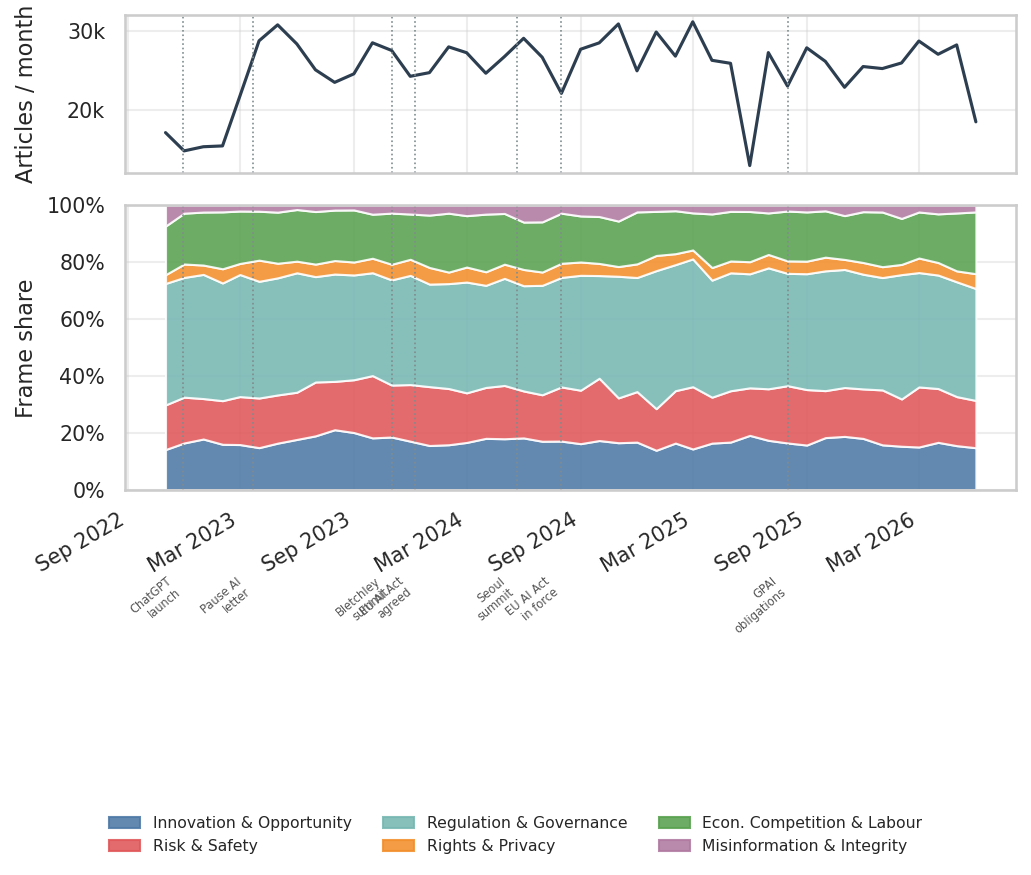

Saved ../paper/figures/fig1_volume_frames.png  |  size: [7.  4.5] in


In [8]:
# Figure 1
vol    = monthly_volume_agg(agg_df)
shares = frame_shares_agg(agg_df)
vol_dates    = vol.index.to_timestamp()
shares_dates = shares.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(TWO_COL_IN, 4.5),
    gridspec_kw={'height_ratios': [1, 1.8]},
    sharex=True,
)

# ── Panel A: monthly volume ──────────────────────────────────────────────────
ax1.plot(vol_dates, vol.values, linewidth=1.5, color='#2c3e50')
ax1.set_ylabel('Articles / month')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)

# ── Panel B: stacked frame proportions ──────────────────────────────────────
present = [c for c in FRAME_ORDER if c in shares.columns]
ax2.stackplot(
    shares_dates,
    [shares[c].values for c in present],
    colors=[FRAME_COLORS[c] for c in present],
    labels=[FRAME_LABELS[c] for c in present],
    alpha=0.88,
)
ax2.set_ylim(0, 1)
ax2.set_ylabel('Frame share')
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x*100)}%')
)

# ── Milestone lines + labels ─────────────────────────────────────────────────
# Labels use a blended transform (x = data coords, y = axes fraction).
# y = -0.30 places them well below the rotated month tick labels (~-0.05 to -0.15).
from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax2.transData, ax2.transAxes)

for name, ts in MILESTONE_DATES.items():
    for ax in (ax1, ax2):
        ax.axvline(ts, color='#7f8c8d', linestyle=':', linewidth=0.8)
    ax2.text(
        ts, -0.30,
        MILESTONE_SHORT.get(name, name),  # keep \n for 2-line labels: shorter width
        transform=trans,
        rotation=40, ha='right', va='top',
        fontsize=5.5, color='#555555', clip_on=False,
    )

# ── x-axis ───────────────────────────────────────────────────────────────────
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Shared legend below both panels ─────────────────────────────────────────
handles = [
    mpatches.Patch(color=FRAME_COLORS[c], label=FRAME_LABELS[c], alpha=0.88)
    for c in present
]
fig.legend(
    handles=handles,
    loc='lower center', ncol=3,
    bbox_to_anchor=(0.5, -0.30),
    fontsize=7.5, frameon=False,
)

fig.align_ylabels([ax1, ax2])
plt.tight_layout()

out1 = FIGURES / 'fig1_volume_frames.png'
plt.savefig(out1, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved {out1}  |  size: {fig.get_size_inches()} in')

## Figure 2 — Milestone Effects on Governance Framing  (RQ3)

**Design rationale:** The current fig3 (2 rows × 7 columns = 14 subplots) is unreadable
at ACM column width. The key finding is a *contrast* between early agenda-setting
milestones (drove regulation + risk spikes) and later implementation milestones (no
effect). A 1×4 grid of 4 representative milestones, each showing two overlaid lines
(regulation and risk frame share over ±3 months), communicates this cleanly.

**Milestone selection:**
- `chatgpt_launch` (Nov 2022) — agenda-setting; clear regulation spike
- `bletchley_summit` (Nov 2023) — contested event; regulation spike documented
- `eu_ai_act_in_force` (Aug 2024) — implementation; documented null result
- `gpai_obligations` (Aug 2025) — implementation; documented null result

`eu_ai_act_agreement` (Dec 2023) is excluded from this figure because its ±3-month
window overlaps almost entirely with Bletchley (5 weeks apart); the two cannot be
disentangled and the limitation is noted in the paper's Discussion.

A slope chart alternative (all 7 milestones) follows in the next cell.

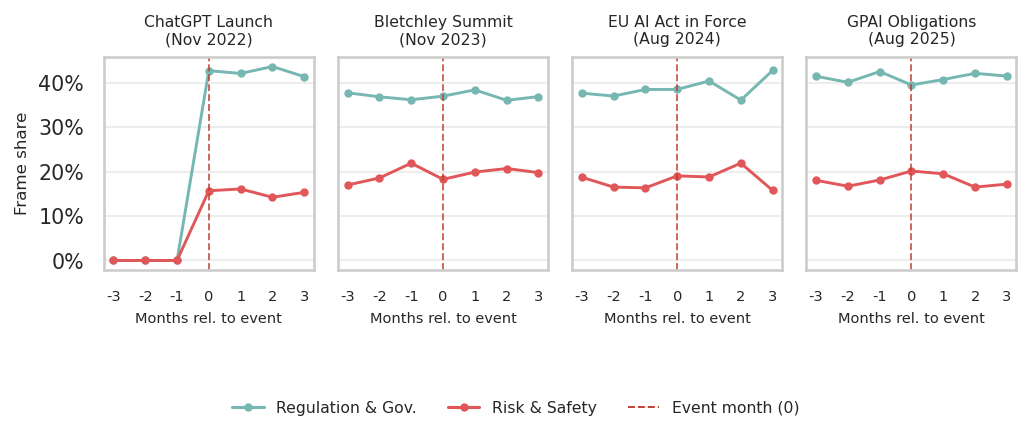

Saved ../paper/figures/fig2_milestone_effects.png  |  size: [7.  2.4] in


In [9]:
# Figure 2 — PRIMARY: 1×4 grid
SELECTED_MILESTONES = [
    ('chatgpt_launch',     'ChatGPT Launch\n(Nov 2022)'),
    ('bletchley_summit',   'Bletchley Summit\n(Nov 2023)'),
    ('eu_ai_act_in_force', 'EU AI Act in Force\n(Aug 2024)'),
    ('gpai_obligations',   'GPAI Obligations\n(Aug 2025)'),
]
FOCUS = {
    'regulation_governance': ('Regulation & Gov.',  FRAME_COLORS['regulation_governance']),
    'risk_safety':           ('Risk & Safety',      FRAME_COLORS['risk_safety']),
}

fig2, axes2 = plt.subplots(
    1, 4,
    figsize=(TWO_COL_IN, 2.4),
    sharey=True,
)

for ax, (mname, mlabel) in zip(axes2, SELECTED_MILESTONES):
    res = event_study_agg(agg_df, mname)
    for fkey, (flabel, fcolor) in FOCUS.items():
        if fkey in res['shares'].columns:
            ax.plot(
                res['shares'].index,
                res['shares'][fkey].values,
                marker='o', markersize=3,
                linewidth=1.4, color=fcolor, label=flabel,
            )
    ax.axvline(0, color='#c0392b', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.set_xticks(range(-3, 4))
    ax.set_xticklabels([str(i) for i in range(-3, 4)], fontsize=7)
    ax.set_title(mlabel, fontsize=7.5)
    ax.set_xlabel('Months rel. to event', fontsize=7)
    ax.grid(axis='y', alpha=0.35)
    ax.grid(axis='x', alpha=0)

axes2[0].set_ylabel('Frame share', fontsize=8)
axes2[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

handles2 = [
    plt.Line2D([0], [0], color=c, linewidth=1.5, marker='o', markersize=3, label=l)
    for _, (l, c) in FOCUS.items()
]
handles2.append(
    plt.Line2D([0], [0], color='#c0392b', linewidth=0.9,
               linestyle='--', label='Event month (0)')
)
fig2.legend(
    handles=handles2,
    loc='lower center', ncol=3,
    bbox_to_anchor=(0.5, -0.22),
    fontsize=7.5, frameon=False,
)

plt.tight_layout()
out2 = FIGURES / 'fig2_milestone_effects.png'
plt.savefig(out2, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved {out2}  |  size: {fig2.get_size_inches()} in')

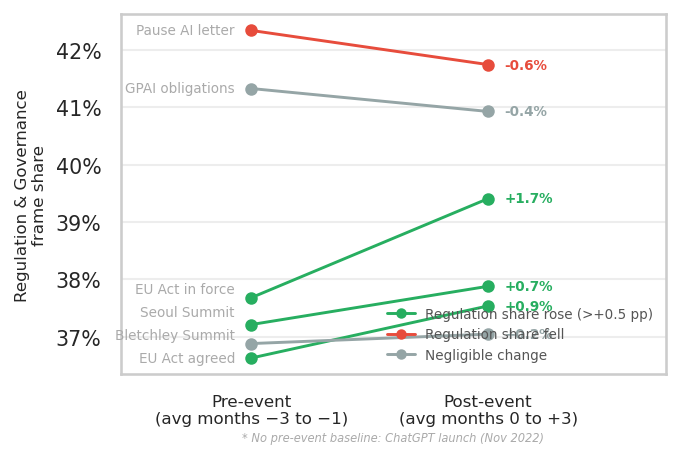

Saved ../paper/figures/fig2b_slope_chart.png  |  size: [4.662 3.2  ] in
Excluded: ['ChatGPT launch (Nov 2022)']


In [10]:
# Figure 2 — ALTERNATIVE: slope chart (milestones with a valid pre-event baseline)
#
# Pre  = mean regulation_governance share over months −3 to −1.
# Post = mean regulation_governance share over months  0 to +3.
# ChatGPT launch excluded: pre-window falls before the study period (data artifact).
#
# Visual hierarchy:
#   Milestone name labels (left)  → light grey (#aaa) — reference text
#   Delta labels (right)          → line color (green/red/grey) — key finding
#   Legend                        → darker grey (#555) — standard

_MILESTONE_LABELS_SLOPE = {
    'pause_ai_letter':      'Pause AI letter',
    'bletchley_summit':     'Bletchley Summit',
    'eu_ai_act_agreement':  'EU Act agreed',
    'seoul_summit':         'Seoul Summit',
    'eu_ai_act_in_force':   'EU Act in force',
    'gpai_obligations':     'GPAI obligations',
}
_NO_BASELINE = {'chatgpt_launch'}

# ── Collect all entries first so we can resolve label overlaps ───────────────
entries = []   # (pre, post, delta, color, label)
excluded = []

for m in MILESTONES:
    if m['name'] in _NO_BASELINE:
        excluded.append('ChatGPT launch (Nov 2022)')
        continue

    res = event_study_agg(agg_df, m['name'])
    reg = res['shares'].get('regulation_governance', pd.Series(dtype=float))
    pre_vals  = reg[reg.index < 0]
    post_vals = reg[reg.index >= 0]

    if (pre_vals != 0).sum() < 2:
        excluded.append(_MILESTONE_LABELS_SLOPE.get(m['name'], m['name']))
        continue

    pre   = pre_vals.mean()
    post  = post_vals.mean()
    delta = post - pre
    color = ('#27ae60' if delta >  0.005
             else '#e74c3c' if delta < -0.005
             else '#95a5a6')
    label = _MILESTONE_LABELS_SLOPE.get(m['name'], m['name'])
    entries.append((pre, post, delta, color, label))

# ── Nudge left-label y-positions apart so overlapping labels don't collide ───
MIN_LABEL_GAP = 0.004   # 0.4 pp minimum vertical gap between adjacent labels
entries.sort(key=lambda e: e[0])
label_ys = [e[0] for e in entries]
for i in range(1, len(label_ys)):
    if label_ys[i] - label_ys[i - 1] < MIN_LABEL_GAP:
        label_ys[i] = label_ys[i - 1] + MIN_LABEL_GAP

# ── Draw ─────────────────────────────────────────────────────────────────────
fig2b, ax2b = plt.subplots(figsize=(ONE_COL_IN * 1.4, 3.2))

for (pre, post, delta, color, label), label_y in zip(entries, label_ys):
    ax2b.plot([0, 1], [pre, post], '-o', color=color,
              linewidth=1.4, markersize=5, zorder=3)
    # Milestone name: light grey — secondary reference
    ax2b.text(-0.07, label_y, label,
              ha='right', va='center', fontsize=6.5, color='#aaaaaa')
    # Delta: line color — primary finding
    ax2b.text(1.07, post, f'{delta:+.1%}',
              ha='left', va='center', fontsize=6.5, color=color, fontweight='bold')

ax2b.set_xticks([0, 1])
ax2b.set_xticklabels(
    ['Pre-event\n(avg months −3 to −1)', 'Post-event\n(avg months 0 to +3)'],
    fontsize=8,
)
ax2b.set_ylabel('Regulation & Governance\nframe share', fontsize=8)
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2b.set_xlim(-0.55, 1.75)
ax2b.grid(axis='y', alpha=0.35)
ax2b.grid(axis='x', alpha=0)

if excluded:
    ax2b.text(0.5, -0.16,
              f'* No pre-event baseline: {"; ".join(excluded)}',
              transform=ax2b.transAxes, ha='center', va='top',
              fontsize=5.5, color='#aaa', style='italic', clip_on=False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], color='#27ae60', lw=1.4, marker='o', ms=4,
           label='Regulation share rose (>+0.5 pp)'),
    Line2D([0],[0], color='#e74c3c', lw=1.4, marker='o', ms=4,
           label='Regulation share fell'),
    Line2D([0],[0], color='#95a5a6', lw=1.4, marker='o', ms=4,
           label='Negligible change'),
]
ax2b.legend(handles=legend_handles, fontsize=6.5, loc='lower right',
            frameon=False, labelcolor='#555555')

plt.tight_layout()
out2b = FIGURES / 'fig2b_slope_chart.png'
plt.savefig(out2b, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved {out2b}  |  size: {fig2b.get_size_inches()} in')
if excluded:
    print(f'Excluded: {excluded}')

## Figure 3 — Regional Frame Distribution

**Design rationale:** Replaces both the stacked-bar fig4 (hard to compare regions
across frames) and the 6-panel time-series fig7 (too complex for a paper figure).
The pooled whole-corpus comparison already tells the key story — EU coverage is
more risk-framed, US coverage is more regulation- and innovation-framed — and the
temporal nuance belongs in the Discussion as a caveat.

A horizontal grouped bar chart with one group per frame lets the reader easily
compare all three regions side-by-side for every frame at once.

Requires `data/interim/gdelt_preprocessed.parquet`.

Region × frame shares:
        innovation_opportunity  risk_safety  regulation_governance  rights_privacy  economic_competition_labour  misinformation_integrity
region                                                                                                                                   
EU                        9.8%        27.5%                  42.7%            3.6%                        14.0%                      2.4%
UK                       10.2%        23.0%                  48.9%            4.5%                        11.9%                      1.5%
US                       12.4%        16.3%                  51.7%            2.8%                        13.9%                      2.9%



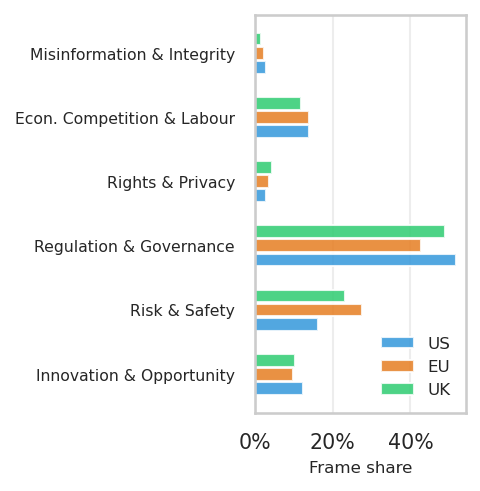

Saved ../paper/figures/fig3_regional.png  |  size: [3.33 3.4 ] in


In [11]:
# Figure 3
if df_raw is None:
    print('Raw corpus not found — skipping Figure 3.')
else:
    reg = region_comparison(df_raw)  # index=region, cols=frame short names
    print('Region × frame shares:')
    print(reg.to_string(float_format='{:.1%}'.format))
    print()

    REGION_COLORS = {'US': '#3498db', 'EU': '#e67e22', 'UK': '#2ecc71'}
    regions_present = [r for r in ['US', 'EU', 'UK'] if r in reg.index]
    frame_names     = [f for f in FRAME_ORDER if f in reg.columns]
    y_labels        = [FRAME_LABELS[f] for f in frame_names]

    n_frames  = len(frame_names)
    n_regions = len(regions_present)
    bar_h     = 0.22
    y_base    = np.arange(n_frames)

    fig3, ax3 = plt.subplots(figsize=(ONE_COL_IN, 3.4))

    for i, region in enumerate(regions_present):
        offset  = (i - (n_regions - 1) / 2) * bar_h
        values  = [reg.loc[region, f] for f in frame_names]
        ax3.barh(
            y_base + offset, values, bar_h * 0.9,
            color=REGION_COLORS.get(region, '#aaa'),
            label=region, alpha=0.85,
        )

    ax3.set_yticks(y_base)
    ax3.set_yticklabels(y_labels, fontsize=7.5)
    ax3.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}')
    )
    ax3.set_xlabel('Frame share', fontsize=8)
    ax3.legend(fontsize=8, loc='lower right', frameon=False)
    ax3.grid(axis='x', alpha=0.35)
    ax3.grid(axis='y', alpha=0)
    ax3.set_axisbelow(True)

    plt.tight_layout()
    out3 = FIGURES / 'fig3_regional.png'
    plt.savefig(out3, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {out3}  |  size: {fig3.get_size_inches()} in')

## Figure 4 — Tone by Frame  (optional)

Horizontal box plot showing tone score distribution per dominant frame, ordered by
median. Adds a valence/sentiment dimension to the framing analysis.

Set `INCLUDE_TONE_FIG = True` to generate and save this figure. It is off by default
because it is supplementary — include it only if space permits in the paper.

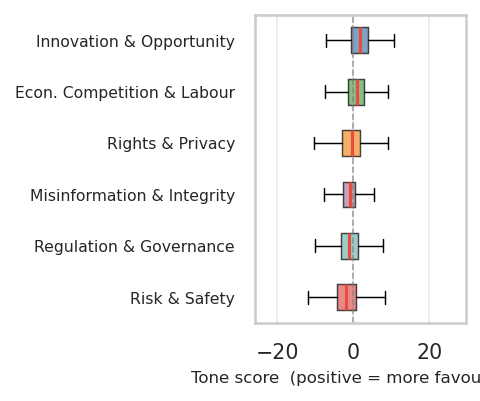

Saved ../paper/figures/fig4_tone_by_frame.png  |  size: [3.33 2.8 ] in


In [12]:
# Figure 4 (optional)
INCLUDE_TONE_FIG = True

if not INCLUDE_TONE_FIG:
    print('INCLUDE_TONE_FIG = False — skipping. Flip to True to generate.')
elif df_raw is None:
    print('Raw corpus not found — skipping Figure 4.')
else:
    _needed = ['dominant_frame', 'tone']
    if not all(c in df_raw.columns for c in _needed):
        print(f'Columns needed: {_needed}. Check preprocessing.')
    else:
        df_tone = df_raw[df_raw['dominant_frame'].notna()].copy()
        frame_order_tone = (
            df_tone.groupby('dominant_frame')['tone'].median()
            .sort_values().index.tolist()
        )
        y_labels_tone = [FRAME_LABELS.get(f, f) for f in frame_order_tone]
        data_by_frame = [
            df_tone.loc[df_tone['dominant_frame'] == f, 'tone'].dropna().values
            for f in frame_order_tone
        ]

        fig4, ax4 = plt.subplots(figsize=(ONE_COL_IN, 2.8))
        bp = ax4.boxplot(
            data_by_frame,
            vert=False,
            patch_artist=True,
            flierprops=dict(marker='.', markersize=1.5, alpha=0.12, markeredgewidth=0),
            medianprops=dict(color='#e74c3c', linewidth=1.5),
            whiskerprops=dict(linewidth=0.7),
            capprops=dict(linewidth=0.7),
            boxprops=dict(linewidth=0.7),
        )
        for patch, fkey in zip(bp['boxes'], frame_order_tone):
            patch.set_facecolor(FRAME_COLORS.get(fkey, '#aaa'))
            patch.set_alpha(0.7)

        ax4.set_yticks(range(1, len(frame_order_tone) + 1))
        ax4.set_yticklabels(y_labels_tone, fontsize=7.5)
        ax4.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
        ax4.set_xlabel('Tone score  (positive = more favourable)', fontsize=8)
        ax4.grid(axis='x', alpha=0.35)
        ax4.grid(axis='y', alpha=0)

        plt.tight_layout()
        out4 = FIGURES / 'fig4_tone_by_frame.png'
        plt.savefig(out4, bbox_inches='tight', dpi=300)
        plt.show()
        print(f'Saved {out4}  |  size: {fig4.get_size_inches()} in')

## Figure — Governance Corpus Coverage  (corpus validation)

**What it shows:** What fraction of all English-language GenAI news is captured by
our governance filter — validating that the corpus is near-comprehensive rather
than a narrow niche topic slice.

- **Left panel — absolute counts:** Stacked area; amber = governance-framed GenAI
  (our corpus), light grey = other GenAI news without governance signal.
  The amber fill dominates, making the comprehensiveness immediately visible.
- **Right panel — share over time:** Governance coverage % per month.
  The dashed line is the 44-month mean (~92.8%).
  A few months exceed 100% (minor artifact: governance query uses REGEXP_CONTAINS,
  total-AI query uses LIKE — they match slightly differently); those are capped at 100%.

Place in the **Methods section** to justify that our corpus captures the overwhelming
majority of AI news, and that coverage is consistent across the study period.

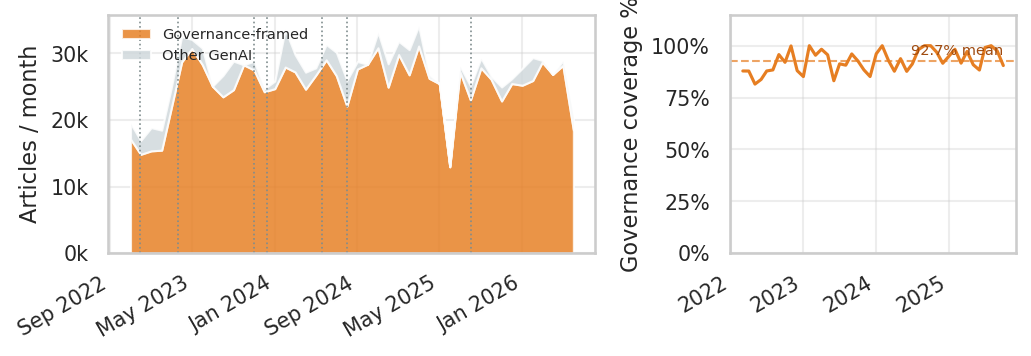

Saved ../paper/figures/fig0_governance_coverage.png  |  size: [7.  2.5] in
Overall governance coverage:  92.7%
Total GenAI articles:         1,191,251
Governance corpus:            1,104,704


In [13]:
# Figure — Governance Corpus Coverage
# Requires data/processed/monthly_ai_total.csv (generated in notebook 02).

COV_PATH = Path('../data/processed/monthly_ai_total.csv')
if not COV_PATH.exists():
    print('monthly_ai_total.csv not found — run the governance coverage cell in 02_frame_labeling.ipynb first.')
else:
    # ── Load and align data ──────────────────────────────────────────────────
    ai_df = pd.read_csv(COV_PATH)
    ai_df['month'] = ai_df['month'].apply(lambda x: pd.Period(x, freq='M'))
    ai_df = ai_df.set_index('month').sort_index()

    gov_counts = agg_df.set_index('month')['total_articles'].rename('gov_articles')
    cov = ai_df.join(gov_counts, how='inner')

    # Cap governance at total for months where query-style mismatch yields >100%
    cov['gov_capped'] = cov[['gov_articles', 'total_ai_articles']].min(axis=1)
    cov['non_gov']    = cov['total_ai_articles'] - cov['gov_capped']
    cov['share']      = cov['gov_capped'] / cov['total_ai_articles']

    overall_share = cov['gov_capped'].sum() / cov['total_ai_articles'].sum()
    dates = cov.index.to_timestamp()

    # ── Figure ───────────────────────────────────────────────────────────────
    fig_cov, (ax_l, ax_r) = plt.subplots(
        1, 2,
        figsize=(TWO_COL_IN, 2.5),
        gridspec_kw={'width_ratios': [1.7, 1]},
    )

    # Left panel: stacked area (governance amber + non-governance grey)
    ax_l.stackplot(
        dates,
        [cov['gov_capped'].values, cov['non_gov'].values],
        colors=['#e67e22', '#cfd8dc'],
        labels=['Governance-framed', 'Other GenAI'],
        alpha=0.83,
    )
    for ts in MILESTONE_DATES.values():
        ax_l.axvline(ts, color='#7f8c8d', linestyle=':', linewidth=0.8)
    ax_l.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax_l.set_ylabel('Articles / month')
    ax_l.xaxis.set_major_locator(mdates.MonthLocator(interval=8))
    ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax_l.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax_l.legend(fontsize=7, loc='upper left', frameon=False)

    # Right panel: governance share % line over time
    ax_r.plot(dates, cov['share'].values * 100,
              color='#e67e22', linewidth=1.5, zorder=3)
    ax_r.axhline(overall_share * 100, color='#e67e22', linestyle='--',
                 linewidth=1.0, alpha=0.7)
    ax_r.text(
        dates[-1], overall_share * 100 + 1.5,
        f'{overall_share:.1%} mean',
        ha='right', va='bottom', fontsize=7, color='#a04b10',
    )
    ax_r.set_ylim(0, 115)
    ax_r.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax_r.set_ylabel('Governance coverage %')
    ax_r.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax_r.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    out_cov = FIGURES / 'fig0_governance_coverage.png'
    plt.savefig(out_cov, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {out_cov}  |  size: {fig_cov.get_size_inches()} in')
    print(f'Overall governance coverage:  {overall_share:.1%}')
    print(f'Total GenAI articles:         {cov["total_ai_articles"].sum():,}')
    print(f'Governance corpus:            {cov["gov_capped"].sum():,}')